In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

In [5]:
# =========================
# 1. Carga de datos
# =========================
file_path = "Datos.xls"
sheet_name = "Ej1"

df = pd.read_excel(file_path, sheet_name=sheet_name)

x = df["m2"]
y = df["precio"]

sns.set(style="whitegrid")

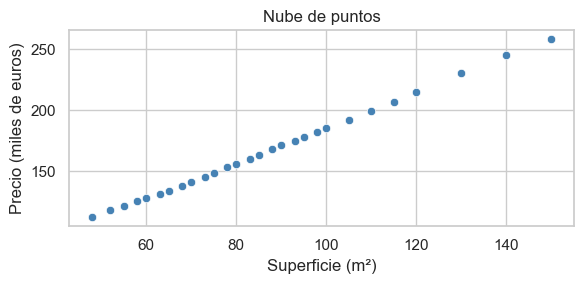

In [6]:

# =========================
# 2. Primer gráfico: solo la nube de puntos
# =========================
plt.figure(figsize=(6, 3))
sns.scatterplot(x=x, y=y, color="steelblue")
plt.xlabel("Superficie (m²)")
plt.ylabel("Precio (miles de euros)")
plt.title("Nube de puntos")
plt.tight_layout()
plt.show()
print()


In [7]:
# =========================
# 3. Ajuste de la recta de regresión
# =========================
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

b0 = model.params["const"]
b1 = model.params["m2"]

print("=== Modelo de regresión lineal ===")
print(model.summary())
print(f"\nIntercepto (b0): {b0:.4f}")
print(f"Pendiente (b1): {b1:.4f} (miles de euros por m²)")
print()


=== Modelo de regresión lineal ===
                            OLS Regression Results                            
Dep. Variable:                 precio   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.570e+04
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           1.01e-43
Time:                        11:35:55   Log-Likelihood:                -37.025
No. Observations:                  28   AIC:                             78.05
Df Residuals:                      26   BIC:                             80.72
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         40.

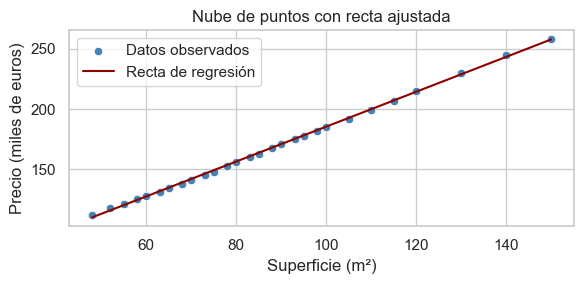

In [8]:

# =========================
# 4. Segundo gráfico: nube + recta ajustada
# =========================
plt.figure(figsize=(6, 3))
sns.scatterplot(x=x, y=y, color="steelblue", label="Datos observados")

x_line = np.linspace(x.min(), x.max(), 100)
X_line = sm.add_constant(x_line)
y_line = model.predict(X_line)

plt.plot(x_line, y_line, color="darkred", label="Recta de regresión")

plt.xlabel("Superficie (m²)")
plt.ylabel("Precio (miles de euros)")
plt.title("Nube de puntos con recta ajustada")
plt.legend()
plt.tight_layout()
plt.show()
print()


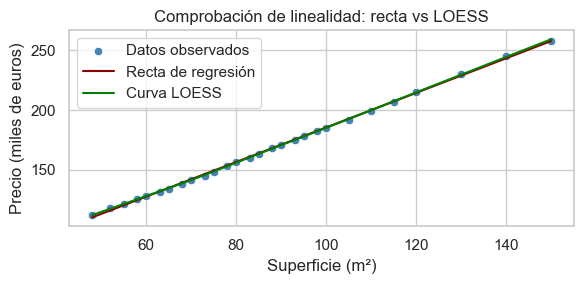

In [9]:
# =========================
# 5. Curva LOESS para comprobar linealidad
# =========================
loess_fit = lowess(y, x, frac=0.6)

plt.figure(figsize=(6, 3))
sns.scatterplot(x=x, y=y, color="steelblue", label="Datos observados")
plt.plot(x_line, y_line, color="darkred", label="Recta de regresión")
plt.plot(loess_fit[:, 0], loess_fit[:, 1], color="green", label="Curva LOESS")

plt.xlabel("Superficie (m²)")
plt.ylabel("Precio (miles de euros)")
plt.title("Comprobación de linealidad: recta vs LOESS")
plt.legend()
plt.tight_layout()
plt.show()
print()


In [10]:

# =========================
# 6. Predicción para una vivienda de 100 m²
# =========================
x0 = 100

# Construir X0 con las mismas columnas que el modelo
X0 = pd.DataFrame({
    "const": [1],
    "m2": [x0]
})

pred = model.get_prediction(X0)
pred_summary = pred.summary_frame(alpha=0.05)

print(f"\n=== Predicción para una vivienda de {x0} m² ===")
print(pred_summary)

precio_esperado = pred_summary["mean"].iloc[0]
ic_inf = pred_summary["mean_ci_lower"].iloc[0]
ic_sup = pred_summary["mean_ci_upper"].iloc[0]
ip_inf = pred_summary["obs_ci_lower"].iloc[0]
ip_sup = pred_summary["obs_ci_upper"].iloc[0]

print(f"\nPrecio medio esperado (miles de euros): {precio_esperado:.2f}")
print(f"IC 95% para la media: [{ic_inf:.2f}, {ic_sup:.2f}]")
print(f"Intervalo de predicción 95%: [{ip_inf:.2f}, {ip_sup:.2f}]")



=== Predicción para una vivienda de 100 m² ===
         mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  185.355466  0.197533     184.949431       185.7615    183.376661   

   obs_ci_upper  
0     187.33427  

Precio medio esperado (miles de euros): 185.36
IC 95% para la media: [184.95, 185.76]
Intervalo de predicción 95%: [183.38, 187.33]


In [11]:
# =========================
# 7. Interpretaciones sugeridas
# =========================
print("\n=== Interpretaciones ===")
print("- b1 indica cuánto aumenta el precio por cada m² adicional.")
print("- b0 suele carecer de interpretación práctica si 0 m² está fuera del rango observado.")
print("- Si LOESS y la recta son similares, la relación lineal es razonable.")
print("- El IC de la media describe la incertidumbre sobre el precio medio esperado.")
print("- El intervalo de predicción describe la variabilidad de una vivienda individual.")



=== Interpretaciones ===
- b1 indica cuánto aumenta el precio por cada m² adicional.
- b0 suele carecer de interpretación práctica si 0 m² está fuera del rango observado.
- Si LOESS y la recta son similares, la relación lineal es razonable.
- El IC de la media describe la incertidumbre sobre el precio medio esperado.
- El intervalo de predicción describe la variabilidad de una vivienda individual.
